# Strategy Backtesting

Backtest combined ML + scalping strategy.

In [1]:
import pandas as pd
import sys
sys.path.append('../src')

from strategy.combined_strategy import generate_combined_strategy
from strategy.backtest import SimpleBacktester

In [3]:
# Load data
ticker = 'AAPL'
from pathlib import Path
# Try multiple relative locations (notebook may run from different working dirs)
candidates = [
    Path('../data/indicators') / f'{ticker}_features.csv',
    Path('../../data/indicators') / f'{ticker}_features.csv',
    Path('../../../data/indicators') / f'{ticker}_features.csv',
    Path('../../../../data/indicators') / f'{ticker}_features.csv',
    Path('../../../../data') / 'indicators' / f'{ticker}_features.csv',
]
for p in candidates:
    if p.exists():
        data = pd.read_csv(p, index_col=0, parse_dates=True)
        print(f'Loaded features from: {p}')
        break
else:
    raise FileNotFoundError(
        f'Could not find {ticker}_features.csv. Checked paths: {', '.join(str(x) for x in candidates)}'
    )

# Generate combined strategy
data = generate_combined_strategy(ticker, data, ml_weight=0.6)

data[['Close', 'ml_signal', 'scalp_signal', 'combined_signal']].tail()

Loaded features from: ..\..\..\..\data\indicators\AAPL_features.csv
2025-12-14 20:05:04 - strategy.combined_strategy - WARNING - No model found for AAPL, using scalping only


2025-12-14 20:05:04 - strategy.scalping_logic - INFO - Generated scalping signals for 1436 rows
2025-12-14 20:05:04 - strategy.combined_strategy - INFO - Generated combined strategy signals for AAPL


c:\Users\Nihar\Documents\GitHub\oop\SnowMore\algo-trading-project\notebooks\../src\strategy\scalping_logic.py:58: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 0.   0.   0.   0.   0.   0.  -1.5 -1.5 -1.5  0.   0.   0.   0.   0.
  0.   0.   0.   0.   1.5  0.  -1.5 -1.5  0.   0.   0.  -1.5 -1.5 -1.5
 -1.5  0.   0.  -1.5  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 -1.5  0.  -1.5 -1.5  0.   0.   1.5  1.5  0.  -1.5 -1.5  0.   1.5  0.
  0.   0.   0.   0.   0.   0.   0.   1.5  0.   0.   0.   0.  -1.5  0.
 -1.5  0.   0.   0.   0.   1.5  0.   0.   0. ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df['vol_spike'], 'scalp_signal'] *= 1.5


,Close,ml_signal,scalp_signal,combined_signal
2025-12-08 00:00:00,245.380203,0,-1.0,-1
2025-12-09 00:00:00,245.380203,0,-1.0,-1
2025-12-10 00:00:00,245.380203,0,-1.0,-1
2025-12-11 00:00:00,245.380203,0,-1.0,-1
2025-12-12 00:00:00,245.380203,0,-1.0,-1


In [4]:
# Run backtest
backtester = SimpleBacktester(initial_capital=100000, commission=0.001)
results = backtester.backtest(data, signal_column='combined_signal')

print('\nBacktest Results:')
for key, value in results.items():
    print(f'{key}: {value}')

2025-12-14 20:05:08 - strategy.backtest - INFO - Backtest Results:
2025-12-14 20:05:08 - strategy.backtest - INFO - Total Return: 15.28%
2025-12-14 20:05:08 - strategy.backtest - INFO - Final Equity: $115,284.71
2025-12-14 20:05:08 - strategy.backtest - INFO - Total Trades: 13
2025-12-14 20:05:08 - strategy.backtest - INFO - Win Rate: 46.15%
2025-12-14 20:05:08 - strategy.backtest - INFO - Sharpe Ratio: 0.35
2025-12-14 20:05:08 - strategy.backtest - INFO - Max Drawdown: -8.94%

Backtest Results:
total_return: 0.15284714628532545
final_equity: 115284.71462853254
total_trades: 13
win_rate: 0.46153846153846156
sharpe_ratio: 0.3453423187586945
max_drawdown: -0.08943806306338829


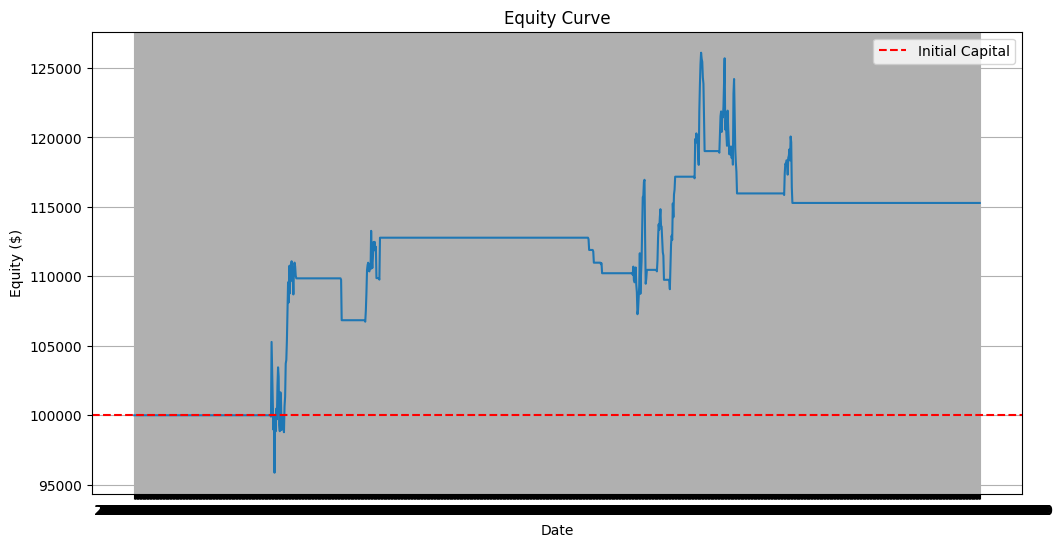

In [5]:
# Plot equity curve
backtester.plot_equity_curve()

In [6]:
# Compare with buy-and-hold
buy_hold_return = (data['Close'].iloc[-1] - data['Close'].iloc[0]) / data['Close'].iloc[0]
print(f'Buy-and-Hold Return: {buy_hold_return:.2%}')
print(f'Strategy Return: {results["total_return"]:.2%}')
print(f'Outperformance: {(results["total_return"] - buy_hold_return):.2%}')

Buy-and-Hold Return: 228.46%
Strategy Return: 15.28%
Outperformance: -213.17%
